In [1]:
# ==============================
# 1️⃣ Import Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [12]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\olham\Desktop\New folder\student-por.csv",
    sep=";"
)

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [13]:
# ===============================
# 2. Data Quality Assessment
# ===============================

# 2.1 Check Data Types
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [14]:
# ===============================
# 2.2 Convert Incorrect Data Types
# ===============================

# Convert categorical (object) columns to category type
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Ensure grades are numeric
df['G1'] = pd.to_numeric(df['G1'])
df['G2'] = pd.to_numeric(df['G2'])
df['G3'] = pd.to_numeric(df['G3'])

df.dtypes

C:\Users\olham\AppData\Local\Temp\ipykernel_23828\2358175666.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


school        category
sex           category
age              int64
address       category
famsize       category
Pstatus       category
Medu             int64
Fedu             int64
Mjob          category
Fjob          category
reason        category
guardian      category
traveltime       int64
studytime        int64
failures         int64
schoolsup     category
famsup        category
paid          category
activities    category
nursery       category
higher        category
internet      category
romantic      category
famrel           int64
freetime         int64
goout            int64
Dalc             int64
Walc             int64
health           int64
absences         int64
G1               int64
G2               int64
G3               int64
dtype: object

In [15]:
missing = df.isna().sum()

missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage (%)": missing_percent
})

,Missing Count,Missing Percentage (%)
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


In [16]:
# Create a copy so we don't damage original data
df_missing = df.copy()

# Introduce missing values in G3 (final grade)
df_missing.loc[0:5, 'G3'] = np.nan

df_missing.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            6
dtype: int64

In [17]:
# Compare shapes
print("Original shape:", df.shape)
print("After introducing missing values:", df_missing.shape)

Original shape: (649, 33)
After introducing missing values: (649, 33)


In [18]:
# ===============================
# Strategy 1: Remove Records
# ===============================

# Remove rows that contain missing values
df_removed = df_missing.dropna()

print("Before removing missing values:", df_missing.shape)
print("After removing missing values:", df_removed.shape)

Before removing missing values: (649, 33)
After removing missing values: (643, 33)


In [19]:
df_missing = df.copy()

# Introduce missing values in G3
df_missing.loc[0:5, 'G3'] = np.nan

df_missing.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            6
dtype: int64

In [20]:
# Create copy
df_imputed_mean = df_missing.copy()

# Replace missing G3 with mean value
df_imputed_mean['G3'].fillna(df_imputed_mean['G3'].mean(), inplace=True)

df_imputed_mean.isna().sum()

C:\Users\olham\AppData\Local\Temp\ipykernel_23828\2001578480.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_imputed_mean['G3'].fillna(df_imputed_mean['G3'].mean(), inplace=True)


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            6
dtype: int64

In [21]:
df_imputed_mean.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,NaN
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,NaN
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,NaN
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,NaN
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,NaN
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,no,yes,yes,yes,yes,no,5,4,2,1,2,5,6,12,12,NaN
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,13,12,13.0
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,2,10,13,13.0
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,2,2,1,1,1,0,15,16,17.0
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,no,yes,yes,yes,yes,no,5,5,1,1,1,5,0,12,12,13.0


C:\Users\olham\AppData\Local\Temp\ipykernel_23828\2923746158.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_imputed_median[col].fillna(df_imputed_median[col].median(), inplace=True)
C:\Users\olham\AppData\Local\Temp\ipykernel_23828\2923746158.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            6
dtype: int64

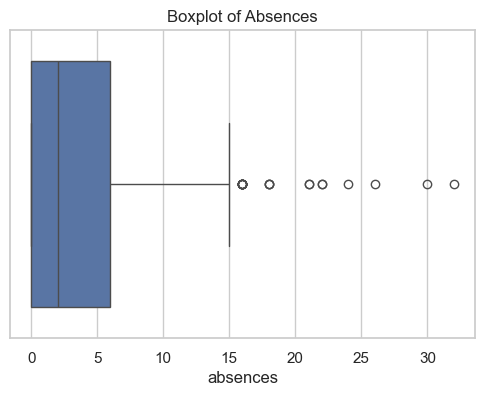

In [23]:
# ===============================
# 4. Handling Outliers
# ===============================

plt.figure(figsize=(6,4))
sns.boxplot(x=df['absences'])
plt.title("Boxplot of Absences")
plt.show()

In [24]:
# Calculate Q1 and Q3
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)

# Interquartile Range
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['absences'] < lower) | (df['absences'] > upper)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 21


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
40,GP,F,16,U,LE3,T,2,2,other,other,home,mother,2,2,0,no,yes,no,yes,no,yes,yes,yes,3,3,3,1,2,3,16,11,11,10
103,GP,F,15,U,GT3,T,3,2,services,other,home,mother,2,2,0,yes,yes,no,no,yes,yes,yes,no,4,3,5,1,1,2,16,11,10,10
150,GP,F,15,U,GT3,A,3,3,services,services,home,mother,1,2,0,no,no,no,no,no,yes,no,yes,1,3,2,2,3,1,24,9,8,9
155,GP,M,17,U,GT3,T,2,1,other,other,home,mother,1,1,0,no,yes,no,no,yes,yes,yes,no,5,4,5,1,2,5,22,9,7,6
161,GP,M,16,U,GT3,T,4,4,teacher,teacher,course,mother,1,1,0,no,yes,no,no,yes,no,yes,yes,3,3,2,2,1,5,16,9,9,8


In [25]:
df_no_outliers = df[(df['absences'] >= lower) & (df['absences'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (649, 33)
After removing outliers: (628, 33)


In [26]:
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [27]:
df_no_outliers = df[(df['absences'] >= lower) & (df['absences'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (649, 33)
After removing outliers: (628, 33)


In [28]:
df[['age', 'absences', 'G1', 'G2', 'G3']].head()

,age,absences,G1,G2,G3
0,18,4,0,11,11
1,17,2,9,11,11
2,15,6,12,13,12
3,15,0,14,14,14
4,16,0,11,13,13


In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select numerical columns
numeric_cols = ['age', 'absences', 'G1', 'G2', 'G3']

df_scaled = df[numeric_cols].copy()

df_scaled[numeric_cols] = scaler.fit_transform(df_scaled)

df_scaled.head()

ModuleNotFoundError: No module named 'sklearn'

In [30]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 6.5 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.0 MB 7.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 7.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/36.5 MB 11.7 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/36.5 MB 11.6 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/36.5 MB 11.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/36.5 MB 11.6 MB/s eta 0:00:03
   ------------ --------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Select numerical columns
numeric_cols = ['age', 'absences', 'G1', 'G2', 'G3']

df_scaled = df[numeric_cols].copy()

df_scaled[numeric_cols] = scaler.fit_transform(df_scaled)

df_scaled.head()

,age,absences,G1,G2,G3
0,0.428571,0.1250,0.000000,0.578947,0.578947
1,0.285714,0.0625,0.473684,0.578947,0.578947
2,0.000000,0.1875,0.631579,0.684211,0.631579
3,0.000000,0.0000,0.736842,0.736842,0.736842
4,0.142857,0.0000,0.578947,0.684211,0.684211


In [32]:
numeric_cols = ['age', 'absences', 'G1', 'G2', 'G3']

df_scaled = df[numeric_cols].copy()

for col in numeric_cols:
    df_scaled[col] = (df_scaled[col] - df_scaled[col].min()) / \
                     (df_scaled[col].max() - df_scaled[col].min())

df_scaled.head()

,age,absences,G1,G2,G3
0,0.428571,0.1250,0.000000,0.578947,0.578947
1,0.285714,0.0625,0.473684,0.578947,0.578947
2,0.000000,0.1875,0.631579,0.684211,0.631579
3,0.000000,0.0000,0.736842,0.736842,0.736842
4,0.142857,0.0000,0.578947,0.684211,0.684211


In [33]:
numeric_cols = ['age', 'studytime', 'absences', 'G1', 'G2', 'G3']

df_numeric = df[numeric_cols]

df_numeric.head()

,age,studytime,absences,G1,G2,G3
0,18,2,4,0,11,11
1,17,2,2,9,11,11
2,15,2,6,12,13,12
3,15,3,0,14,14,14
4,16,2,0,11,13,13
